![PwC Logo](pwc-logo.png)

# Customer Churn EDA
Exploratory analysis of telecom churn dataset (7,043 customers, 23 features).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_excel('02 Churn-Dataset.xlsx')
print(df.shape)

(7043, 23)


## Background
Telecom is a crowded market, and customers don't hesitate to switch providers when they find a better deal, better service, or simply a better experience. Each customer who leaves takes their monthly revenue with them, and those losses quietly add up across a base this size. So before any fix can be recommended, a few real questions need answers. Who is actually churning? What's pushing them out the door? And how early can the business spot it coming? This notebook works through the data to answer those questions, building toward a practical way to flag at-risk customers before they leave.

## 1. Data Cleaning

In [2]:
# TotalCharges is object — coerce whitespace/empty to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Customers with tenure=0 have blank TotalCharges — fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Binary encode target
df['Churned'] = (df['Churn'] == 'Yes').astype(int)

print('Missing values after cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nChurn rate: {df["Churned"].mean():.1%}')

Missing values after cleaning:
Series([], dtype: int64)

Churn rate: 26.5%


## 2. Overview

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Churn Distribution

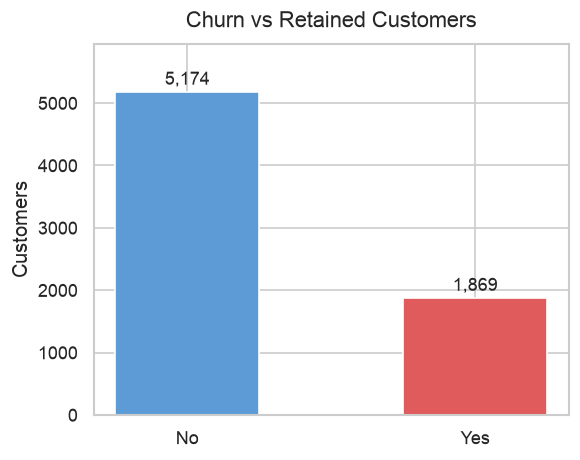

Churn
No     5174
Yes    1869


In [4]:
counts = df['Churn'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index, counts.values, color=['#5c9bd6', '#e05c5c'], width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Churn vs Retained Customers', fontsize=13, pad=10)
ax.set_ylabel('Customers')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()
print(counts.to_string())

## 4. Churn by Categorical Features

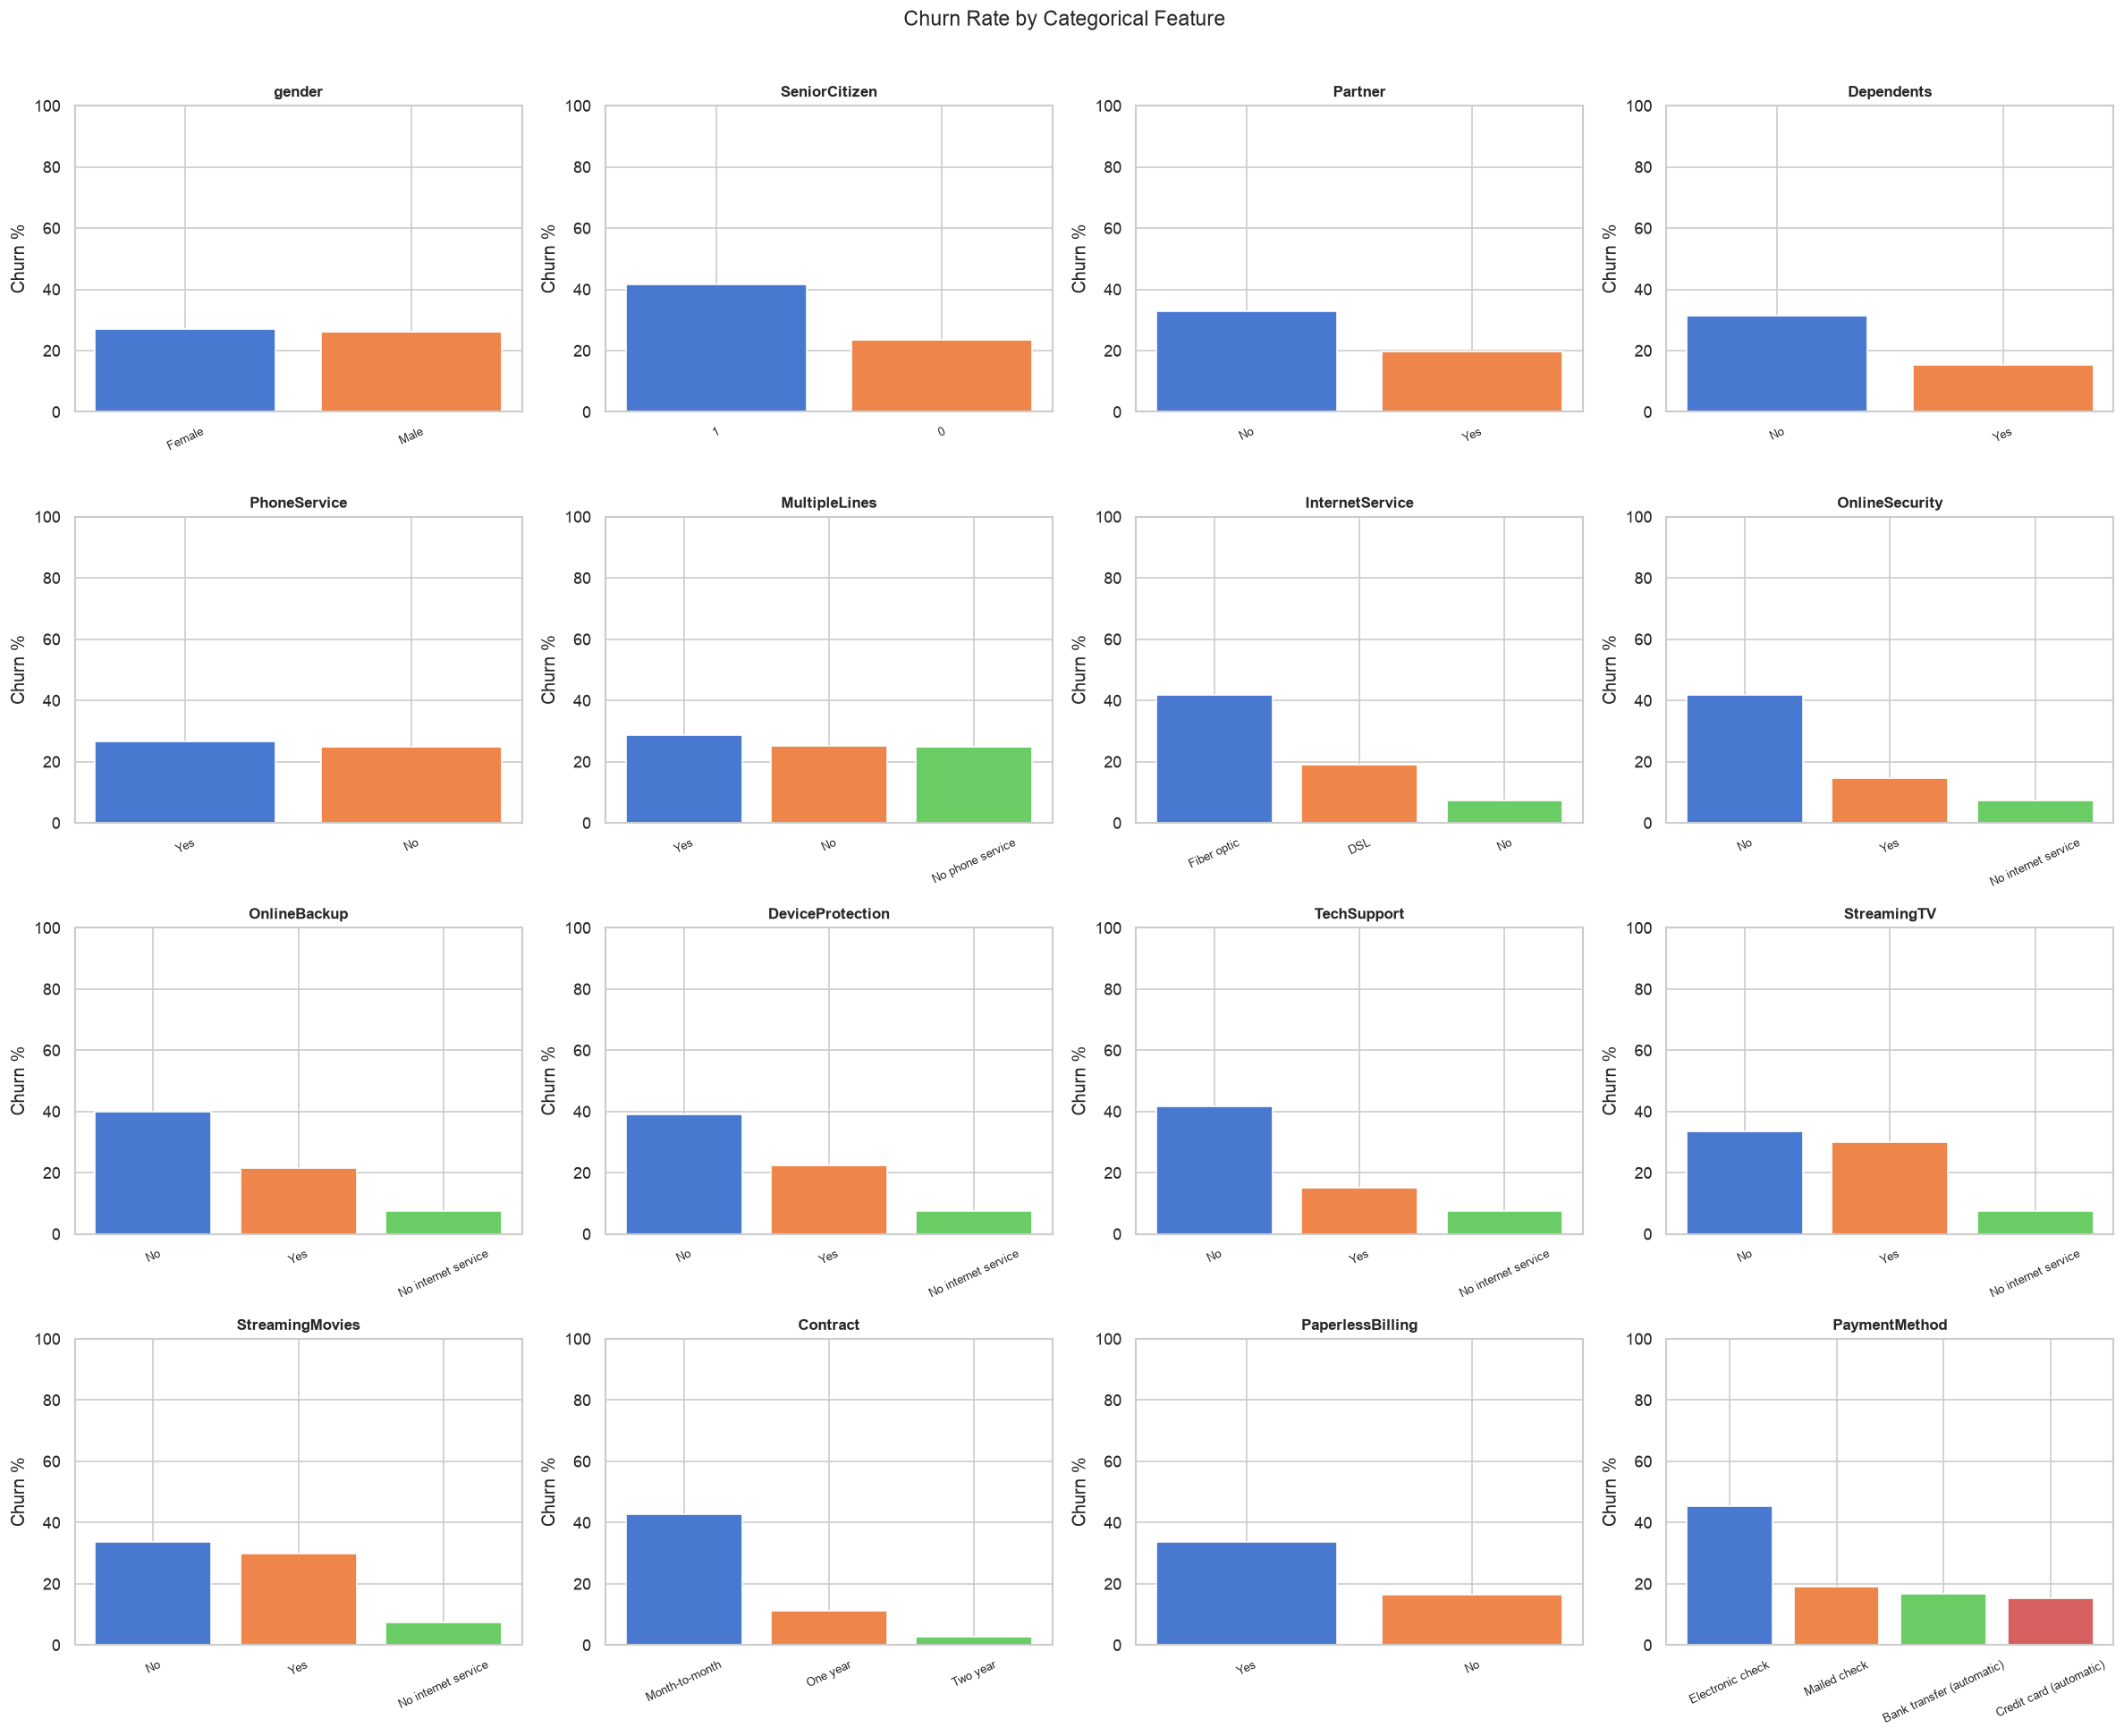

In [5]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rates = df.groupby(col)['Churned'].mean().sort_values(ascending=False)
    axes[i].bar(churn_rates.index.astype(str), churn_rates.values * 100,
                color=sns.color_palette('muted', len(churn_rates)))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Churn %')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=25, labelsize=8)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Churn by Numerical Features

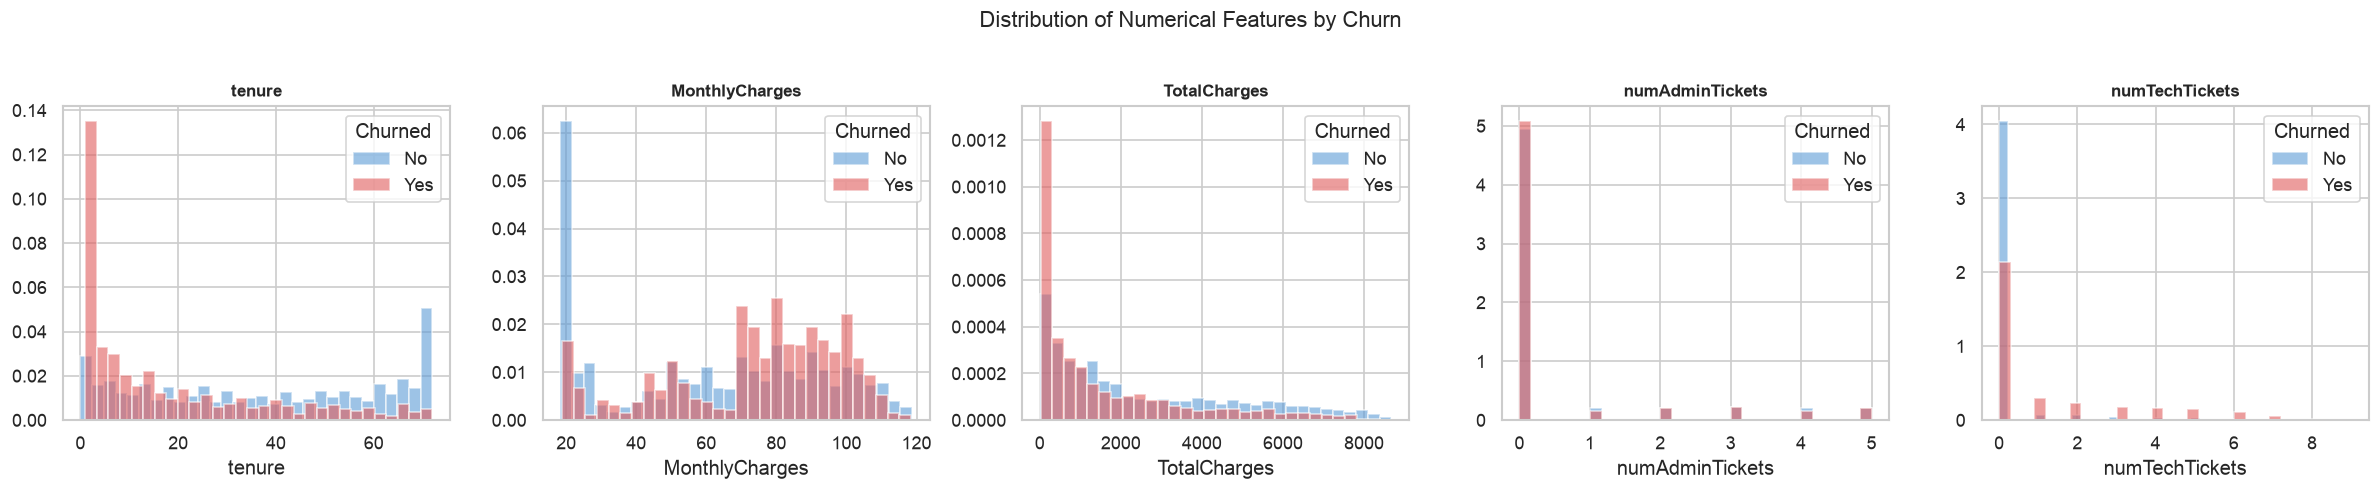

In [6]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'numAdminTickets', 'numTechTickets']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))

for ax, col in zip(axes, num_cols):
    for label, color in [('No', '#5c9bd6'), ('Yes', '#e05c5c')]:
        subset = df[df['Churn'] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(title='Churned')

plt.suptitle('Distribution of Numerical Features by Churn', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap (Numerical)

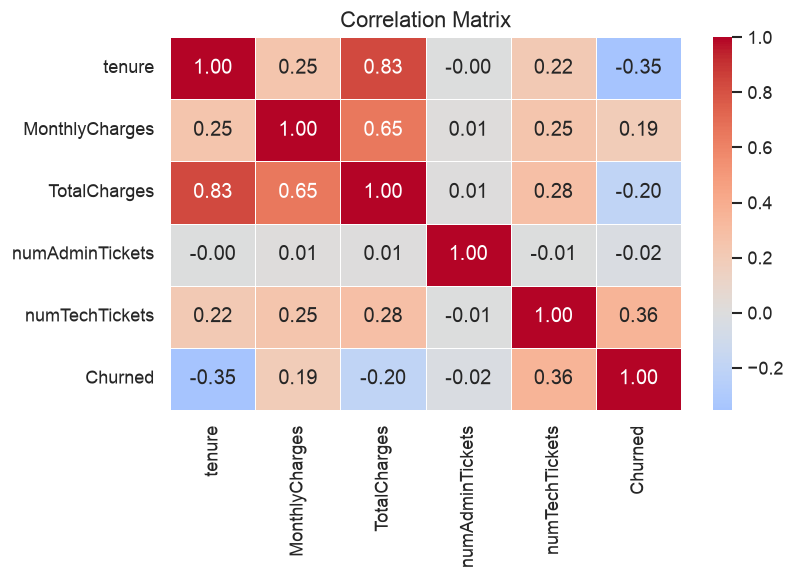

In [7]:
num_df = df[num_cols + ['Churned']]
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Tenure vs Monthly Charges

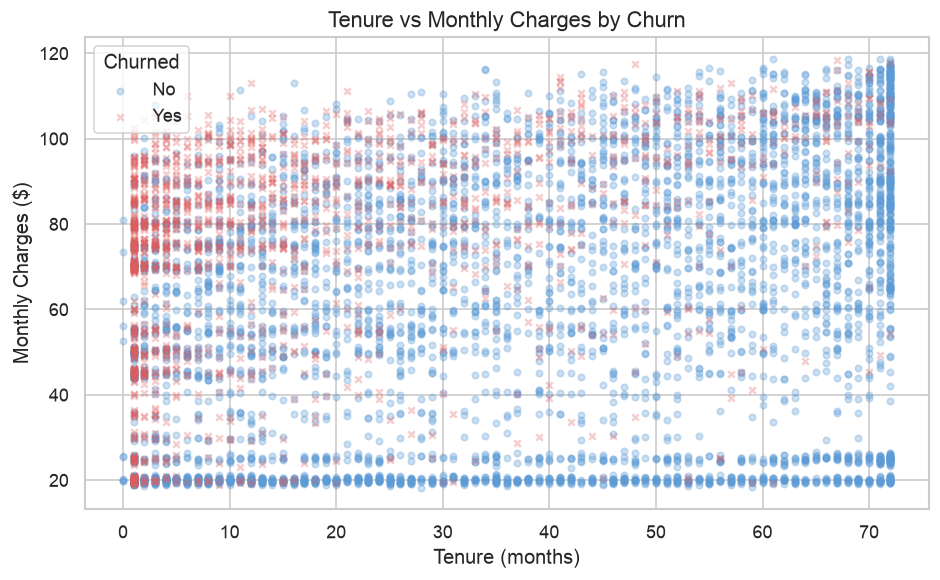

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, color, marker in [('No', '#5c9bd6', 'o'), ('Yes', '#e05c5c', 'x')]:
    subset = df[df['Churn'] == label]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'],
               alpha=0.3, s=15, color=color, marker=marker, label=label)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
ax.set_title('Tenure vs Monthly Charges by Churn', fontsize=13)
ax.legend(title='Churned')
plt.tight_layout()
plt.show()

## 8. Key Takeaways

In [9]:
overall_churn = df['Churned'].mean()

print(f'Overall churn rate: {overall_churn:.1%}\n')
print('--- Highest churn segments ---')

segments = {
    'Contract: Month-to-month': df[df['Contract'] == 'Month-to-month']['Churned'].mean(),
    'Internet: Fiber optic': df[df['InternetService'] == 'Fiber optic']['Churned'].mean(),
    'No Online Security': df[df['OnlineSecurity'] == 'No']['Churned'].mean(),
    'No Tech Support': df[df['TechSupport'] == 'No']['Churned'].mean(),
    'Paperless Billing: Yes': df[df['PaperlessBilling'] == 'Yes']['Churned'].mean(),
    'Senior Citizen': df[df['SeniorCitizen'] == 1]['Churned'].mean(),
    'Tenure < 12 months': df[df['tenure'] < 12]['Churned'].mean(),
}

for segment, rate in sorted(segments.items(), key=lambda x: -x[1]):
    print(f'  {segment}: {rate:.1%}  ({rate/overall_churn:.1f}x baseline)')

Overall churn rate: 26.5%

--- Highest churn segments ---
  Tenure < 12 months: 48.3%  (1.8x baseline)
  Contract: Month-to-month: 42.7%  (1.6x baseline)
  Internet: Fiber optic: 41.9%  (1.6x baseline)
  No Online Security: 41.8%  (1.6x baseline)
  Senior Citizen: 41.7%  (1.6x baseline)
  No Tech Support: 41.6%  (1.6x baseline)
  Paperless Billing: Yes: 33.6%  (1.3x baseline)


## 9. Revenue at Risk
Who churns matters less than *how much revenue* they take with them.

Total MRR:          $456,117
MRR lost to churn:  $139,131  (30.5% of revenue)
Churners are 26.5% of customers but 30.5% of revenue

      Contract  customers  churners  churn_rate  mrr_at_risk  mrr_at_risk_pct
Month-to-month       3875      1655    0.427097    120847.10         0.264948
      One year       1473       166    0.112695     14118.45         0.030954
      Two year       1695        48    0.028319      4165.30         0.009132


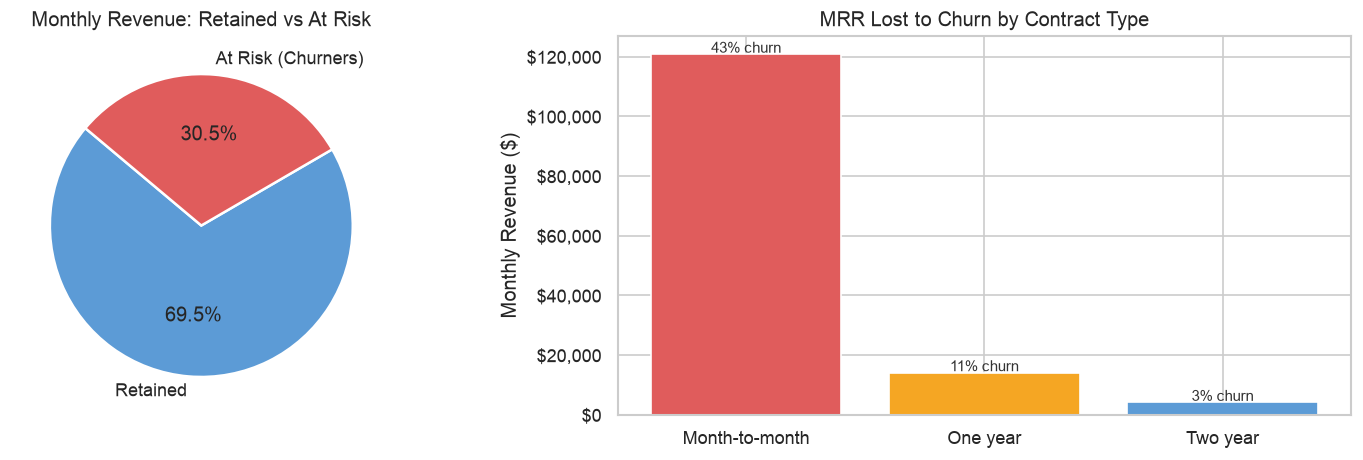

In [10]:
total_mrr = df['MonthlyCharges'].sum()
churner_mrr = df[df['Churned'] == 1]['MonthlyCharges'].sum()
churner_pct_customers = df['Churned'].mean()
churner_pct_revenue = churner_mrr / total_mrr

print(f'Total MRR:          ${total_mrr:,.0f}')
print(f'MRR lost to churn:  ${churner_mrr:,.0f}  ({churner_pct_revenue:.1%} of revenue)')
print(f'Churners are {churner_pct_customers:.1%} of customers but {churner_pct_revenue:.1%} of revenue')
print()

rev_by_contract = df.groupby('Contract').agg(
    customers=('customerID', 'count'),
    churners=('Churned', 'sum'),
    churn_rate=('Churned', 'mean'),
    mrr_at_risk=('MonthlyCharges', lambda x: x[df.loc[x.index, 'Churned'] == 1].sum())
).reset_index()
rev_by_contract['mrr_at_risk_pct'] = rev_by_contract['mrr_at_risk'] / total_mrr
print(rev_by_contract.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

retained_mrr = total_mrr - churner_mrr
axes[0].pie([retained_mrr, churner_mrr],
            labels=['Retained', 'At Risk (Churners)'],
            colors=['#5c9bd6', '#e05c5c'],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Monthly Revenue: Retained vs At Risk', fontsize=12)

axes[1].bar(rev_by_contract['Contract'], rev_by_contract['mrr_at_risk'],
            color=['#e05c5c', '#f5a623', '#5c9bd6'])
axes[1].set_title('MRR Lost to Churn by Contract Type', fontsize=12)
axes[1].set_ylabel('Monthly Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (_, row) in enumerate(rev_by_contract.iterrows()):
    axes[1].text(i, row['mrr_at_risk'] + 500, f"{row['churn_rate']:.0%} churn",
                 ha='center', fontsize=9, color='#333')

plt.tight_layout()
plt.show()

## 10. Service Bundle Effect
Does subscribing to more services make customers stickier?

 ServiceCount  customers  churn_rate  avg_monthly
            0         80    0.437500    24.903750
            1       2253    0.216600    32.998779
            2        996    0.434739    65.527861
            3       1041    0.346782    73.164697
            4       1062    0.272128    82.568362
            5        827    0.220073    89.446312
            6        525    0.125714    95.408857
            7        259    0.057915   102.696911


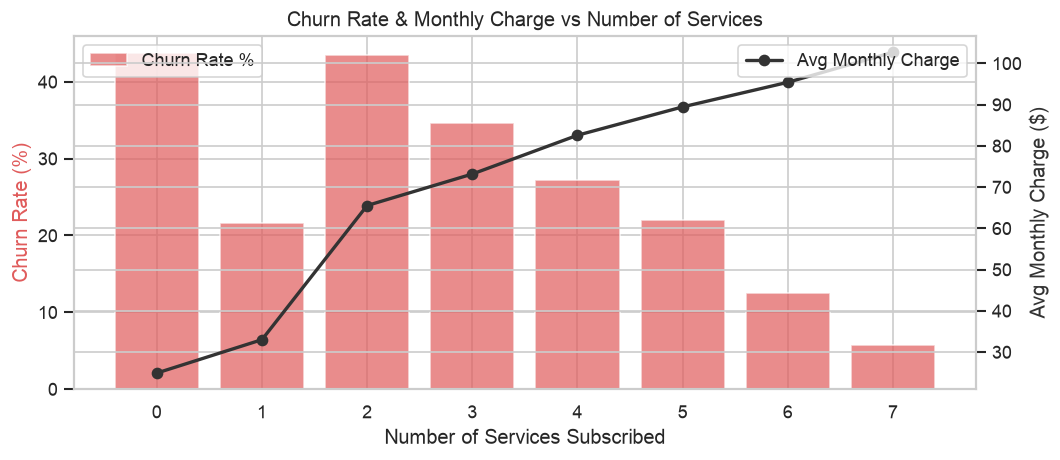

In [11]:
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['ServiceCount'] = df[service_cols].apply(lambda col: (col == 'Yes').astype(int)).sum(axis=1)

bundle = df.groupby('ServiceCount').agg(
    customers=('customerID', 'count'),
    churn_rate=('Churned', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean')
).reset_index()

print(bundle.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

bars = ax1.bar(bundle['ServiceCount'], bundle['churn_rate'] * 100,
               color='#e05c5c', alpha=0.7, label='Churn Rate %')
line, = ax2.plot(bundle['ServiceCount'], bundle['avg_monthly'],
                 color='#333', marker='o', linewidth=2, label='Avg Monthly Charge')

ax1.set_xlabel('Number of Services Subscribed')
ax1.set_ylabel('Churn Rate (%)', color='#e05c5c')
ax2.set_ylabel('Avg Monthly Charge ($)', color='#333')
ax1.set_title('Churn Rate & Monthly Charge vs Number of Services', fontsize=12)
ax1.set_xticks(bundle['ServiceCount'])
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 11. The Fiber Optic Paradox
Fiber customers pay more *and* churn more. What's actually driving it?

=== Fiber Optic vs DSL ===

Fiber optic  (n=3,096)
  Churn rate:       41.9%
  Avg monthly:      $91.50
  Avg tech tickets: 0.70
  Month-to-month:   68.7%

DSL  (n=2,421)
  Churn rate:       19.0%
  Avg monthly:      $58.10
  Avg tech tickets: 0.25
  Month-to-month:   50.5%


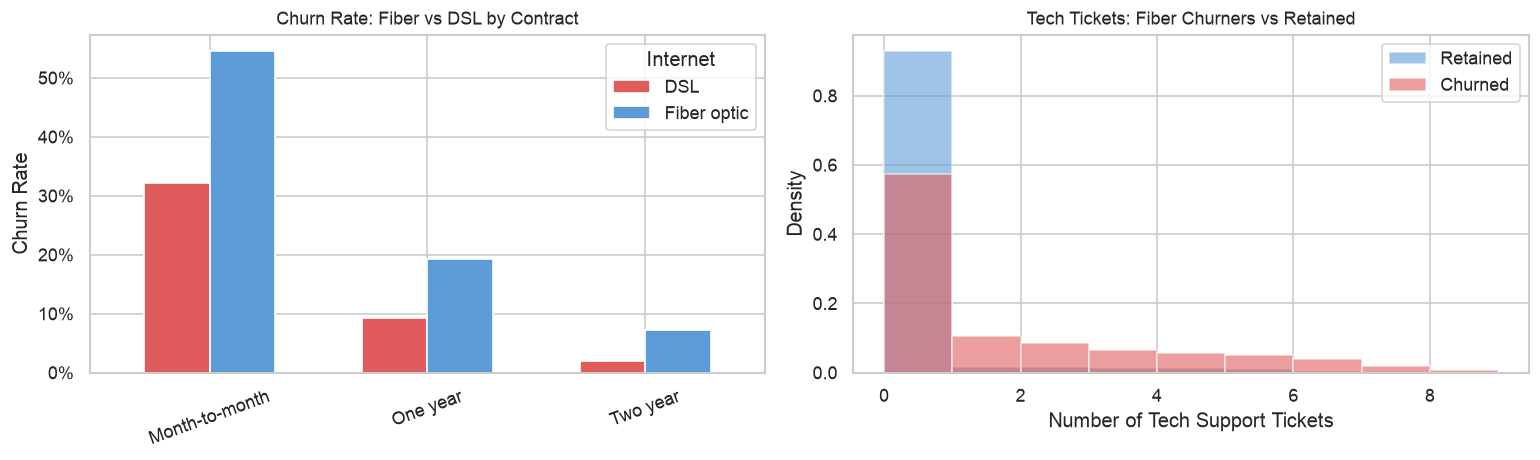

In [12]:
fiber = df[df['InternetService'] == 'Fiber optic'].copy()
dsl = df[df['InternetService'] == 'DSL'].copy()

print('=== Fiber Optic vs DSL ===')
for label, subset in [('Fiber optic', fiber), ('DSL', dsl)]:
    print(f"\n{label}  (n={len(subset):,})")
    print(f"  Churn rate:       {subset['Churned'].mean():.1%}")
    print(f"  Avg monthly:      ${subset['MonthlyCharges'].mean():.2f}")
    print(f"  Avg tech tickets: {subset['numTechTickets'].mean():.2f}")
    print(f"  Month-to-month:   {(subset['Contract'] == 'Month-to-month').mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cross = df[df['InternetService'].isin(['Fiber optic', 'DSL'])].groupby(
    ['InternetService', 'Contract'])['Churned'].mean().unstack()
cross.T.plot(kind='bar', ax=axes[0], color=['#e05c5c', '#5c9bd6'], width=0.6)
axes[0].set_title('Churn Rate: Fiber vs DSL by Contract', fontsize=11)
axes[0].set_ylabel('Churn Rate')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend(title='Internet')

for label, color in [('Retained', '#5c9bd6'), ('Churned', '#e05c5c')]:
    subset = fiber[fiber['Churned'] == (1 if label == 'Churned' else 0)]
    axes[1].hist(subset['numTechTickets'], bins=range(0, 10),
                 alpha=0.6, color=color, label=label, density=True)
axes[1].set_title('Tech Tickets: Fiber Churners vs Retained', fontsize=11)
axes[1].set_xlabel('Number of Tech Support Tickets')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Support Tickets as a Churn Signal
Is there a ticket volume tipping point where churn spikes?

 TotalTickets  customers  churn_rate
            0       5031    0.201352
            1        404    0.403465
            2        380    0.386842
            3        380    0.376316
            4        343    0.379009
            5        320    0.412500
            6         86    0.790698
            7         44    0.750000
            8         23    0.826087


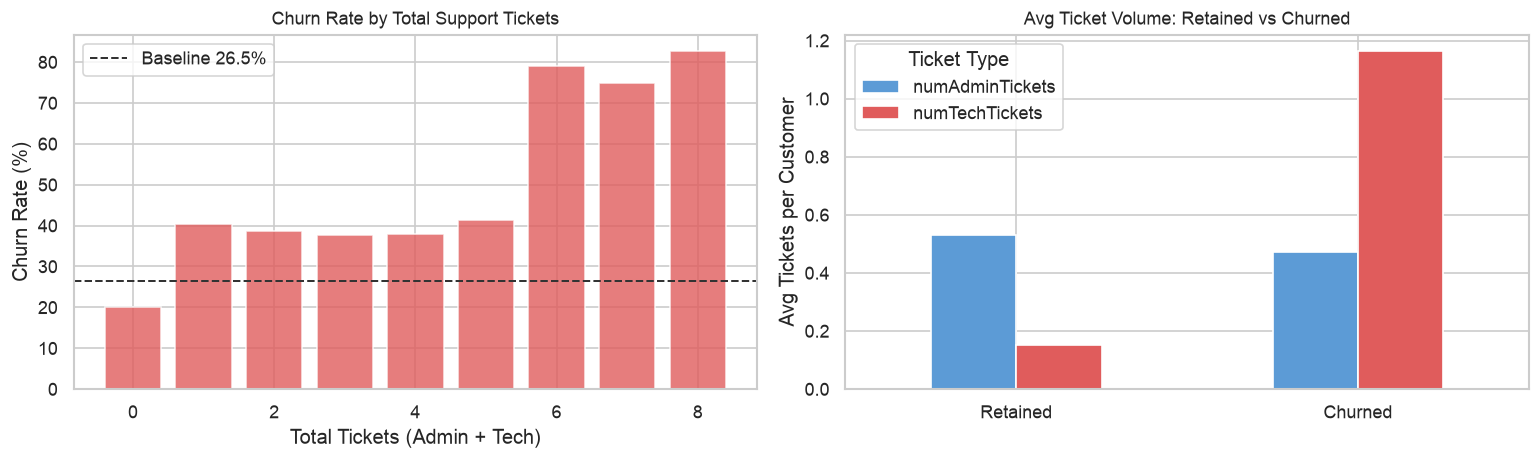

In [13]:
df['TotalTickets'] = df['numAdminTickets'] + df['numTechTickets']

ticket_churn = df.groupby('TotalTickets').agg(
    customers=('customerID', 'count'),
    churn_rate=('Churned', 'mean')
).reset_index()
ticket_churn = ticket_churn[ticket_churn['customers'] >= 20]

print(ticket_churn.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(ticket_churn['TotalTickets'], ticket_churn['churn_rate'] * 100,
            color='#e05c5c', alpha=0.8)
axes[0].axhline(df['Churned'].mean() * 100, color='#333', linestyle='--', linewidth=1.2,
                label=f'Baseline {df["Churned"].mean():.1%}')
axes[0].set_title('Churn Rate by Total Support Tickets', fontsize=11)
axes[0].set_xlabel('Total Tickets (Admin + Tech)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].legend()

means = df.groupby('Churned')[['numAdminTickets', 'numTechTickets']].mean()
means.index = ['Retained', 'Churned']
means.plot(kind='bar', ax=axes[1], color=['#5c9bd6', '#e05c5c'], width=0.5)
axes[1].set_title('Avg Ticket Volume: Retained vs Churned', fontsize=11)
axes[1].set_ylabel('Avg Tickets per Customer')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Ticket Type')

plt.tight_layout()
plt.show()

## 13. High-Value Churner Profile
The customers who hurt most to lose — high paying, already gone.

Charge threshold (top 20%): $94.25/month
High-value churners: 467  (25.0% of all churners)
Revenue at risk from high-value churners: $47,301/month

High-value churner profile:
  Avg monthly charge: $101.29
  Avg tenure:         33.0 months
  Month-to-month:     75.4%
  Fiber optic:        100.0%
  No tech support:    70.9%


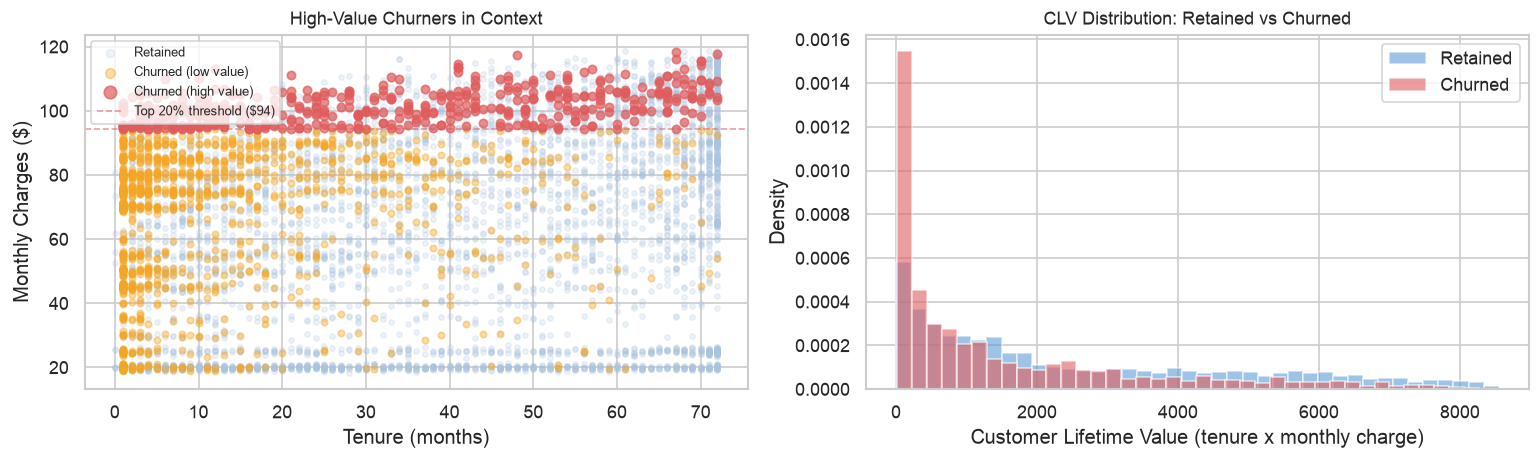

In [14]:
churners = df[df['Churned'] == 1].copy()
df['CLV'] = df['tenure'] * df['MonthlyCharges']
churners['CLV'] = churners['tenure'] * churners['MonthlyCharges']

charge_threshold = df['MonthlyCharges'].quantile(0.80)
high_value_churners = churners[churners['MonthlyCharges'] >= charge_threshold]

print(f'Charge threshold (top 20%): ${charge_threshold:.2f}/month')
print(f'High-value churners: {len(high_value_churners):,}  ({len(high_value_churners)/len(churners):.1%} of all churners)')
print(f'Revenue at risk from high-value churners: ${high_value_churners["MonthlyCharges"].sum():,.0f}/month')
print()
print('High-value churner profile:')
print(f'  Avg monthly charge: ${high_value_churners["MonthlyCharges"].mean():.2f}')
print(f'  Avg tenure:         {high_value_churners["tenure"].mean():.1f} months')
print(f'  Month-to-month:     {(high_value_churners["Contract"] == "Month-to-month").mean():.1%}')
print(f'  Fiber optic:        {(high_value_churners["InternetService"] == "Fiber optic").mean():.1%}')
print(f'  No tech support:    {(high_value_churners["TechSupport"] == "No").mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

retained = df[df['Churned'] == 0]
low_churners = churners[churners['MonthlyCharges'] < charge_threshold]

axes[0].scatter(retained['tenure'], retained['MonthlyCharges'],
                alpha=0.2, s=10, color='#aac4e0', label='Retained')
axes[0].scatter(low_churners['tenure'], low_churners['MonthlyCharges'],
                alpha=0.4, s=15, color='#f5a623', label='Churned (low value)')
axes[0].scatter(high_value_churners['tenure'], high_value_churners['MonthlyCharges'],
                alpha=0.7, s=25, color='#e05c5c', label='Churned (high value)')
axes[0].axhline(charge_threshold, color='#e05c5c', linestyle='--', linewidth=1,
                alpha=0.6, label=f'Top 20% threshold (${charge_threshold:.0f})')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].set_title('High-Value Churners in Context', fontsize=11)
axes[0].legend(markerscale=1.5, fontsize=8)

axes[1].hist(df[df['Churned'] == 0]['CLV'], bins=40, alpha=0.6, color='#5c9bd6',
             label='Retained', density=True)
axes[1].hist(churners['CLV'], bins=40, alpha=0.6, color='#e05c5c',
             label='Churned', density=True)
axes[1].set_xlabel('Customer Lifetime Value (tenure x monthly charge)')
axes[1].set_ylabel('Density')
axes[1].set_title('CLV Distribution: Retained vs Churned', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

## 14. Customer Risk Scoring
Flag active customers most likely to leave using additive risk signals — no ML needed.

Risk score validation (does score correlate with actual churn?):
 RiskScore  customers  churn_rate
         0       1203    0.010806
         1       1079    0.038925
         2       1196    0.147993
         3       1061    0.237512
         4       1169    0.404619
         5        979    0.663943
         6        336    0.738095
         7         20    0.700000

Active customers with risk score >= 5: 423
Combined MRR at risk: $34,194/month


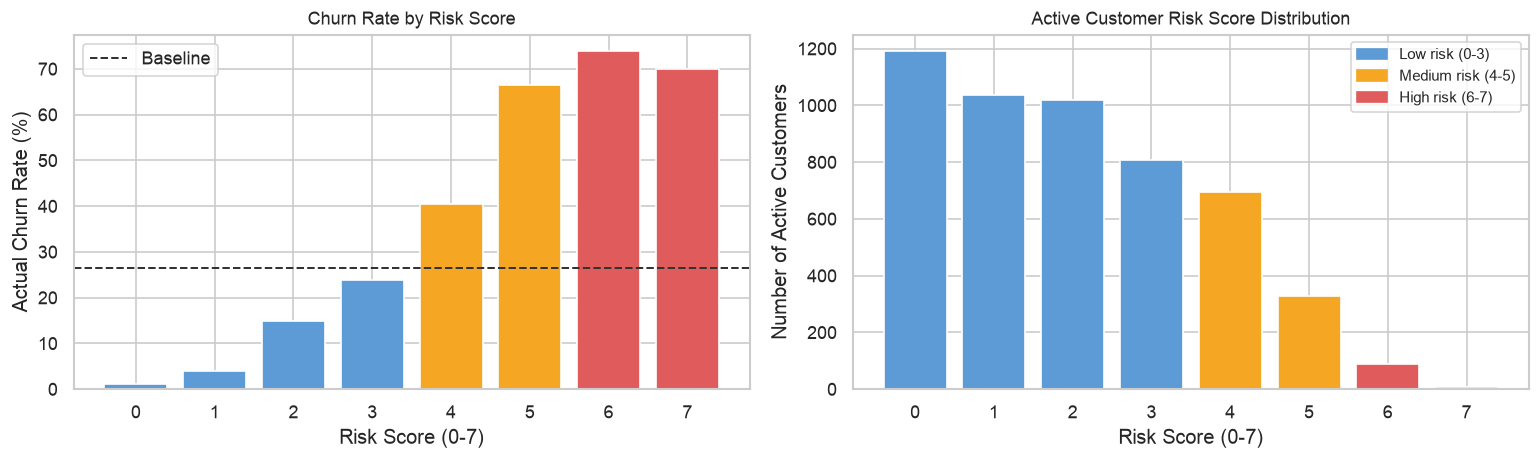


Top 10 highest-risk active customers:
customerID  MonthlyCharges  tenure       Contract InternetService  RiskScore
5150-ITWWB           94.85       3 Month-to-month     Fiber optic          7
6350-XFYGW           94.75       4 Month-to-month     Fiber optic          7
0187-QSXOE           89.00       7 Month-to-month     Fiber optic          7
8775-ERLNB           74.30       1 Month-to-month     Fiber optic          7
3295-YVUSR           72.60       2 Month-to-month     Fiber optic          7
3420-ZDBMA           71.45       5 Month-to-month     Fiber optic          7
2378-VTKDH          104.35      65 Month-to-month     Fiber optic          6
6851-WEFYX          100.80      35 Month-to-month     Fiber optic          6
1013-QCWAM          100.80      66 Month-to-month     Fiber optic          6
2754-SDJRD          100.15       8 Month-to-month     Fiber optic          6


In [15]:
df['risk_mtm']     = (df['Contract'] == 'Month-to-month').astype(int)
df['risk_fiber']   = (df['InternetService'] == 'Fiber optic').astype(int)
df['risk_no_sec']  = (df['OnlineSecurity'] == 'No').astype(int)
df['risk_no_sup']  = (df['TechSupport'] == 'No').astype(int)
df['risk_new']     = (df['tenure'] < 12).astype(int)
df['risk_tickets'] = (df['TotalTickets'] >= 3).astype(int)
df['risk_senior']  = (df['SeniorCitizen'] == 1).astype(int)

risk_flags = ['risk_mtm', 'risk_fiber', 'risk_no_sec', 'risk_no_sup',
              'risk_new', 'risk_tickets', 'risk_senior']
df['RiskScore'] = df[risk_flags].sum(axis=1)

risk_validation = df.groupby('RiskScore').agg(
    customers=('customerID', 'count'),
    churn_rate=('Churned', 'mean')
).reset_index()
print('Risk score validation (does score correlate with actual churn?):')
print(risk_validation.to_string(index=False))

active = df[df['Churned'] == 0]
high_risk = active[active['RiskScore'] >= 5]
print(f'\nActive customers with risk score >= 5: {len(high_risk):,}')
print(f'Combined MRR at risk: ${high_risk["MonthlyCharges"].sum():,.0f}/month')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['#5c9bd6' if r < 4 else '#f5a623' if r < 6 else '#e05c5c'
          for r in risk_validation['RiskScore']]
axes[0].bar(risk_validation['RiskScore'], risk_validation['churn_rate'] * 100, color=colors)
axes[0].axhline(df['Churned'].mean() * 100, color='#333', linestyle='--',
                linewidth=1.2, label='Baseline')
axes[0].set_xlabel('Risk Score (0-7)')
axes[0].set_ylabel('Actual Churn Rate (%)')
axes[0].set_title('Churn Rate by Risk Score', fontsize=11)
axes[0].legend()

active_risk = active['RiskScore'].value_counts().sort_index()
bar_colors = ['#5c9bd6' if r < 4 else '#f5a623' if r < 6 else '#e05c5c'
              for r in active_risk.index]
axes[1].bar(active_risk.index, active_risk.values, color=bar_colors)
axes[1].set_xlabel('Risk Score (0-7)')
axes[1].set_ylabel('Number of Active Customers')
axes[1].set_title('Active Customer Risk Score Distribution', fontsize=11)

legend_elements = [Patch(color='#5c9bd6', label='Low risk (0-3)'),
                   Patch(color='#f5a623', label='Medium risk (4-5)'),
                   Patch(color='#e05c5c', label='High risk (6-7)')]
axes[1].legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.show()

print('\nTop 10 highest-risk active customers:')
top_risk = (high_risk[['customerID', 'MonthlyCharges', 'tenure', 'Contract',
                        'InternetService', 'RiskScore']]
            .sort_values(['RiskScore', 'MonthlyCharges'], ascending=[False, False])
            .head(10))
print(top_risk.to_string(index=False))